# 2021 Turkish GP(Istanbul Park) - Strategy Post Mortem: A Gamble That Almost Worked

## The Racing Question:
Charles Leclerc lead the Turkish Grand Prix for several laps on aging intermediate tires while Valtteri Bottas pitted for fresh rubber. The gamble nearly worked for Ferrari; Leclerc actually led the Grand Prix. So why did he finish the race P4(missing out the podium entirely) while Bottas won?

## What Happened:
- Lap 36: Bottas pits for fresh intermediates from pole position, conceding the lead to preserve tire life for the remainder of the Grand Prix.
- Laps 37-46: Leclerc stays out on his original set of intermediates, inheriting the net lead by lap 40 as the rest of the grid cycles through their stops. For nearly 10 laps, the gamble looks like the winning call with Leclerc leading the Grand Prix on far older tires than his closest rivals'.
- Lap 47: Leclerc's tires finally degrade past the point Ferrari can justify staying out. Bottas takes the lead into Turn 1 and Leclerc pits for fresh rubber.
-Laps 47-50: The real cost of the gamble shows up here, both RedBulls (Verstappen & Perez) pass Leclerc in this window, capitalizing on Leclerc's cold tires straight out of the pits. Leclerc drops from P2 to P4 and never recovers his spot on the podium.
- Final positions at the end of the Grand Prix: 1- BOT, 2 - VER, 3 - PER, 4 - LEC

## Evidence - Leclerc's Tires and the Red Bulls' Recovery:
Leclerc's raw lap times over his single 47-lap stint show a noisy but loosely upward trend in the second half; consistent with, though not conclusive proof of, tire degradation on its own. As in the Hungary analysis, raw lap time is a weaker signal than a direct gap comparison.

The clearer evidence comes from comparing Leclerc's cumulative gap to both Red Bulls. Verstappen and Pérez pitted in the same lap-36–38 window as Bottas, which initially cost them ~25–30 seconds relative to Leclerc,
who stayed out. But over the following ~9 laps, both Red Bulls closed roughly 10 seconds of that deficit purely on tire pace, evidence that Leclerc's aging intermediates were now the slowest tires on track. By the time Leclerc finally pitted on lap 47, both Red Bulls had closed enough that the pass was a formality rather than a fight.

## A Note on the Lap 37 Spike:
Leclerc's lap 37 time (1:37.8) is a few seconds off his earlier pace, coinciding with a yellow flag noted on lap 38 and a wave of rival pit stops in the same window. Given the proximity of these events, this single-lap spike is better explained by general race disruption than as clean evidence of tire degradation on its own; reinforcing why the gap-based comparison against the Red Bulls (rather than raw lap times) is the stronger evidence in this analysis.

## Why It Matters:
This wasn't a bad read of the track, for most of the second stint Ferrari's gamble was outperforming the conservating Mercedes strategy. The eventual cost came from the *exit* of the pit gamble, not the gamble in itself. An outlap on cold tires directly after a long-overdue stop is one of the most vulnerable moments in the race, and two cars(the RedBulls) were perfectly placed to exploit it.

## Strategist Takeaway:
A strategy call should be judged by its full lifecycle, not just its peak. Holding position on old tires can be the right read of a race for a long stretch, but the moment you are finally forced to pit, you're exposed exactly when your tires are coldest and your rivals' are warmest. The real strategic question isn't "should I stay out?" it's "what does my vulnerability look like the moment I cannot stay out any longer, and who is positioned to take advantage of it?"

## A Note on Method:
An early version of this analysis had the gap chart's sign convention backwards, initally suggesting Bottas was ahead when Leclerc held the net lead for several laps(around laps 37-46). Cross-checking against 'Position' data at key laps(rather than trusting the gap chart's label alone) caught the error; A reminder that a chart's *shape* can be entirely correct while its *label* is wrong, and hard facts(like who actually saw the checkered-flag first) are the right way to verify a chart's story, not just it's internal logic.

In [23]:
#imports
import fastf1
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
#Loading the cache & data for Turkey GP 2021
fastf1.Cache.enable_cache('../data/cache')

session = fastf1.get_session(2021, 'Turkey', 'R')
session.load()

print(session.event['EventName'])
print(session.event['EventDate'])

core           INFO 	Loading data for Turkish Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 77 completed the race distance 00:00.079000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['77', '33', '11', '16', '44', '10', '4', '55', '18', '31', '99', '

Turkish Grand Prix
2021-10-10 00:00:00


In [6]:
#Picking BOT(Bottas) and LEC(Leclerc) for analysis in this case

laps = session.laps

bot_laps = laps.pick_drivers('BOT')
lec_laps = laps.pick_drivers('LEC')

print("Bottas Laps: ", len(bot_laps))
print("Leclerc Laps: ", len(lec_laps))

cols = ['LapNumber', 'LapTime', 'Compound', 'PitInTime', 'PitOutTime', 'TrackStatus']

Bottas Laps:  58
Leclerc Laps:  58


In [7]:
# Printing pit stops for BOT & LEC
bot_pit_laps = bot_laps[bot_laps['PitInTime'].notna()]
lec_pit_laps = lec_laps[lec_laps['PitInTime'].notna()]

print("Bottas pit stops:")
print(bot_pit_laps[cols])

print("\nLeclerc pit stops:")
print(lec_pit_laps[cols])

Bottas pit stops:
    LapNumber                LapTime      Compound              PitInTime  \
36       37.0 0 days 00:01:35.037000  INTERMEDIATE 0 days 02:00:20.678000   

   PitOutTime TrackStatus  
36        NaT           1  

Leclerc pit stops:
     LapNumber                LapTime      Compound              PitInTime  \
220       47.0 0 days 00:01:38.124000  INTERMEDIATE 0 days 02:16:27.683000   

    PitOutTime TrackStatus  
220        NaT           1  


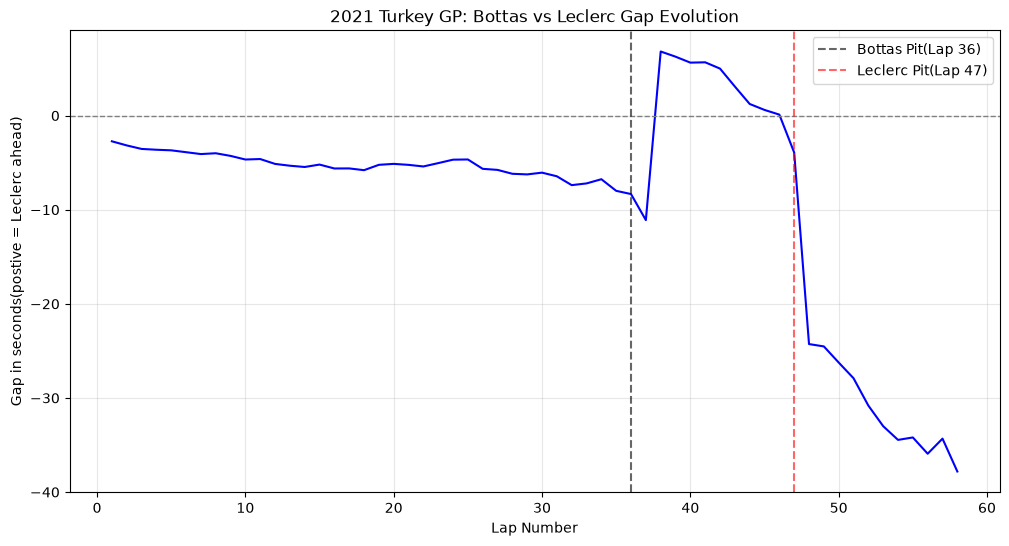

In [15]:
#Building the gap chart for BOT & LEC

merged = pd.merge(
    bot_laps[['LapNumber', 'Time']],
    lec_laps[['LapNumber', 'Time']],
    on='LapNumber',
    suffixes=('_BOT', '_LEC')
)

merged['Gap_BOT_minus_LEC'] = (merged['Time_BOT'] - merged['Time_LEC']).dt.total_seconds()

plt.figure(figsize=(12, 6))
plt.plot(merged['LapNumber'], merged['Gap_BOT_minus_LEC'], color = 'blue')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)


plt.axvline(36, color = 'black', linestyle = '--', alpha = 0.6, label = 'Bottas Pit(Lap 36)')
plt.axvline(47, color = 'red', linestyle = '--', alpha = 0.6, label = 'Leclerc Pit(Lap 47)')

plt.xlabel('Lap Number')
plt.ylabel('Gap in seconds(postive = Leclerc ahead)')
plt.title('2021 Turkey GP: Bottas vs Leclerc Gap Evolution')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

In [ ]:
#position data to double check(see an error on the y-axis of the gap chart, where Bottas is ahead but the gap is negative):
check_laps = [1,20,36,40,46,47,50,58]

bot_pos = bot_laps[bot_laps['LapNumber'].isin(check_laps)][['LapNumber', 'Position']]
lec_pos = lec_laps[lec_laps['LapNumber'].isin(check_laps)][['LapNumber', 'Position']]

print("Bottas:\n", bot_pos)
print("\nLeclerc:\n", lec_pos)

Bottas:
     LapNumber  Position
0         1.0       1.0
19       20.0       1.0
35       36.0       1.0
39       40.0       2.0
45       46.0       2.0
46       47.0       1.0
49       50.0       1.0
57       58.0       1.0

Leclerc:
      LapNumber  Position
174        1.0       3.0
193       20.0       3.0
209       36.0       3.0
213       40.0       1.0
219       46.0       1.0
220       47.0       2.0
223       50.0       4.0
231       58.0       4.0


In [14]:
#checking for which drivers passed Leclerc during the pit stop window (laps 46-48):

final_positions = laps[laps['LapNumber'] == 58][['Driver', 'Position']].sort_values('Position')
print("Final Positions:\n", final_positions)

Final Positions:
     Driver  Position
57     BOT       1.0
115    VER       2.0
173    PER       3.0
231    LEC       4.0
289    HAM       5.0
347    GAS       6.0
405    NOR       7.0
463    SAI       8.0
521    STR       9.0


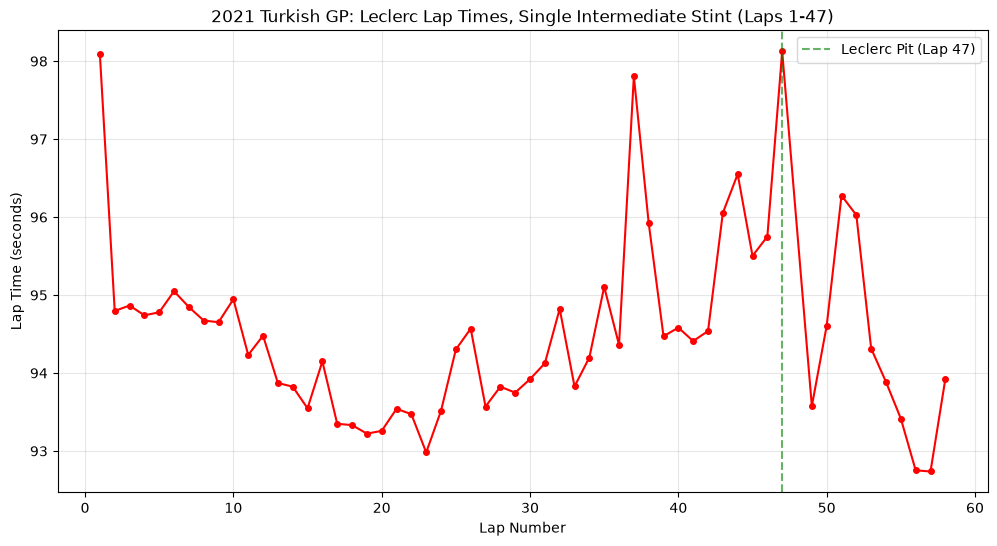

In [17]:
#plot of Leclerc's tire degradation over the Grand Prix:
plt.figure(figsize=(12, 6))

lec_clean = lec_laps.pick_quicklaps()
plt.plot(lec_clean['LapNumber'], lec_clean['LapTime'].dt.total_seconds(), color='red', marker='o', markersize=4)

plt.axvline(47, color='green', linestyle='--', alpha=0.6, label='Leclerc Pit (Lap 47)')

plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.title('2021 Turkish GP: Leclerc Lap Times, Single Intermediate Stint (Laps 1-47)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [20]:
#investigating the sharp spike on lap 37 as seen in the plot above:

# Check track status flags around lap 37
print(lec_laps[lec_laps['LapNumber'].isin([35, 36, 37, 38, 39])][['LapNumber', 'LapTime', 'TrackStatus']])

# Check race control messages around this window
rcm = session.race_control_messages
rcm_window = rcm[(rcm['Lap'] >= 34) & (rcm['Lap'] <= 39)]
print(rcm_window[['Lap', 'Category', 'Message']])

     LapNumber                LapTime TrackStatus
208       35.0 0 days 00:01:35.106000           1
209       36.0 0 days 00:01:34.362000           1
210       37.0 0 days 00:01:37.807000           1
211       38.0 0 days 00:01:35.924000          12
212       39.0 0 days 00:01:34.472000           1
    Lap  Category                                            Message
44   34      Flag  WAVED BLUE FLAG FOR CAR 6 (LAT) TIMED AT 15:55:34
45   34      Flag  WAVED BLUE FLAG FOR CAR 47 (MSC) TIMED AT 15:5...
46   34      Flag  WAVED BLUE FLAG FOR CAR 47 (MSC) TIMED AT 15:5...
47   34      Flag  WAVED BLUE FLAG FOR CAR 9 (MAZ) TIMED AT 15:56:20
48   35      Flag  WAVED BLUE FLAG FOR CAR 6 (LAT) TIMED AT 15:57:03
49   35      Flag  WAVED BLUE FLAG FOR CAR 9 (MAZ) TIMED AT 15:57:14
50   35      Flag  WAVED BLUE FLAG FOR CAR 6 (LAT) TIMED AT 15:57:20
51   36      Flag  WAVED BLUE FLAG FOR CAR 6 (LAT) TIMED AT 15:58:52
52   38      Flag                           YELLOW IN TRACK SECTOR 4
53   38   

In [21]:
#checking if Leclerc was stuck behind a backmarker on lap 37, which could have caused the spike in lap time:

#What position was Leclerc in, and who was near him on track around lap 37?
nearby = laps[laps['LapNumber'] == 37][['Driver', 'Position', 'LapTime']].sort_values('Position')
print(nearby)

     Driver  Position                LapTime
36      BOT       1.0 0 days 00:01:35.037000
210     LEC       2.0 0 days 00:01:37.807000
94      VER       3.0 0 days 00:01:51.505000
268     HAM       4.0 0 days 00:01:35.043000
152     PER       5.0 0 days 00:01:35.737000
326     GAS       6.0 0 days 00:01:34.249000
500     STR       7.0 0 days 00:01:34.822000
384     NOR       8.0 0 days 00:01:34.567000
558     OCO       9.0 0 days 00:01:35.315000
442     SAI      10.0 0 days 00:01:58.582000
615     GIO      11.0 0 days 00:01:35.684000
729     RIC      12.0 0 days 00:01:34.779000
672     RAI      13.0 0 days 00:01:35.857000
786     TSU      14.0 0 days 00:01:35.283000
843     RUS      15.0 0 days 00:01:35.187000
900     ALO      16.0 0 days 00:01:39.063000
957     LAT      17.0 0 days 00:01:36.276000
1014    VET      18.0                    NaT
1071    MSC      19.0 0 days 00:01:35.946000
1127    MAZ      20.0 0 days 00:01:36.248000


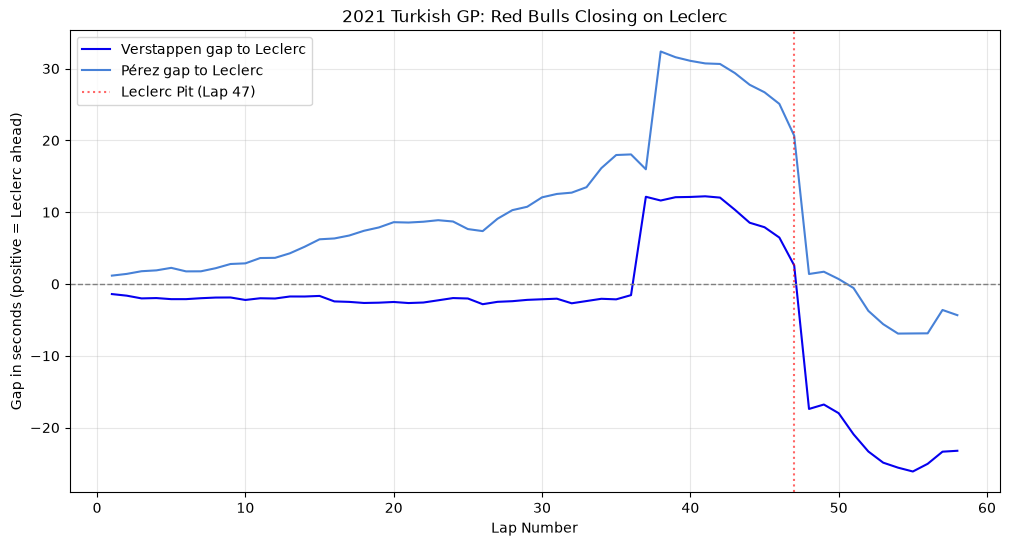

In [18]:
# three-way gap chart for LEC, VER, and PER to visualize how the RedBulls exploited Ferrari's failed gamble:

ver_laps = laps.pick_drivers('VER')
per_laps = laps.pick_drivers('PER')

merged3 = pd.merge(lec_laps[['LapNumber', 'Time']], ver_laps[['LapNumber', 'Time']], on='LapNumber', suffixes=('_LEC', '_VER'))
merged3 = pd.merge(merged3, per_laps[['LapNumber', 'Time']], on='LapNumber')
merged3 = merged3.rename(columns={'Time': 'Time_PER'})

merged3['Gap_VER_to_LEC'] = (merged3['Time_VER'] - merged3['Time_LEC']).dt.total_seconds()
merged3['Gap_PER_to_LEC'] = (merged3['Time_PER'] - merged3['Time_LEC']).dt.total_seconds()

plt.figure(figsize=(12, 6))
plt.plot(merged3['LapNumber'], merged3['Gap_VER_to_LEC'], color='#0600EF', label='Verstappen gap to Leclerc')
plt.plot(merged3['LapNumber'], merged3['Gap_PER_to_LEC'], color='#4781D7', label='Pérez gap to Leclerc')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(47, color='red', linestyle=':', alpha=0.6, label='Leclerc Pit (Lap 47)')

plt.xlabel('Lap Number')
plt.ylabel('Gap in seconds (positive = Leclerc ahead)')
plt.title('2021 Turkish GP: Red Bulls Closing on Leclerc')
plt.legend()
plt.grid(alpha=0.3)
plt.show()